# 02 — Preprocessing, Rule-Based Weak Labeling, Clustering, Pseudo Labeling

Fokus penilaian: **Appropriateness of techniques used in pre-processing (20%)**.

Output notebook ini:
- `outputs/02_modeling_dataset.csv`
- `outputs/02_labeling_report.csv`
- `outputs/02_cluster_profile.csv`

Label yang dibuat adalah **pseudo label**, bukan ground truth eksternal. Rule berbasis domain dipakai sebagai weak supervision, lalu clustering dipakai sebagai support.

In [1]:
from pathlib import Path
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
PROJECT_ROOT=Path.cwd(); OUTPUT_DIR=PROJECT_ROOT/'outputs'; PLOT_DIR=OUTPUT_DIR/'plots'; PLOT_DIR.mkdir(parents=True, exist_ok=True)
if not (OUTPUT_DIR/'01_consolidated_raw.csv').exists(): raise FileNotFoundError('Jalankan Notebook 01 dulu.')
df = pd.read_csv(OUTPUT_DIR/'01_consolidated_raw.csv')
with open(OUTPUT_DIR/'01_actor_config.json','r',encoding='utf-8') as f: ACTOR_CONFIG=json.load(f)
print(df.shape); display(df.head())

(787, 31)


,actor,region,dmu,land_area,land_lease_value_idr,labor_cost_idr,seed_purchase_value_idr,fertilizer_purchase_value_idr,pesticide_purchase_value_idr,equipment_rent_value_idr,production_value_idr,number_of_machines,value_of_milled_grains_idr,amount_of_milled_rice,supporting_equipment_cost_idr,value_of_milled_rice_idr,total_revenue_of_milling_machine_idr,total_rice_purchase_kg,total_rice_purchase_value_idr,building_rent_cost_idr,value_of_rice_sold_idr,total_precipitation,precipitation_quality,value_of_rice_purchase_idr,total_cost,output_value,margin,rc_ratio,margin_ratio,quantity_proxy,cost_per_quantity
0,Farmer,Garut,1,"2,800.0000","4,900,000.0000","1,400,000.0000","644,000.0000","3,640,000.0000","364,000.0000","470,000.0000","16,200,000.0000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"11,418,000.0000","16,200,000.0000","4,782,000.0000",1.4188,0.4188,"2,800.0000","4,077.8571"
1,Farmer,Garut,2,"1,400.0000","4,900,000.0000","500,000.0000","322,000.0000","1,820,000.0000","182,000.0000","540,000.0000","8,100,000.0000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"8,264,000.0000","8,100,000.0000","-164,000.0000",0.9802,-0.0198,"1,400.0000","5,902.8571"
2,Farmer,Garut,3,"2,000.0000","2,000,000.0000","700,000.0000","200,000.0000","2,600,000.0000","260,000.0000","690,000.0000","14,850,000.0000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"6,450,000.0000","14,850,000.0000","8,400,000.0000",2.3023,1.3023,"2,000.0000","3,225.0000"
3,Farmer,Garut,4,"1,000.0000","1,800,000.0000","800,000.0000","230,000.0000","1,300,000.0000","100,000.0000","340,000.0000","13,050,000.0000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"4,570,000.0000","13,050,000.0000","8,480,000.0000",2.8556,1.8556,"1,000.0000","4,570.0000"
4,Farmer,Garut,5,800.0000,"1,520,000.0000","580,000.0000","184,000.0000","1,040,000.0000","104,000.0000","350,000.0000","10,200,000.0000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"3,778,000.0000","10,200,000.0000","6,422,000.0000",2.6998,1.6998,800.0000,"4,722.5000"


In [2]:
# Cleaning dasar
protected={'actor','region'}
for col in df.columns:
    if col not in protected:
        df[col]=pd.to_numeric(df[col], errors='coerce')
df = df.replace([np.inf,-np.inf], np.nan).dropna(subset=['actor','region','dmu']).copy()
dup = df.duplicated(['actor','region','dmu']).sum()
print('Duplicate actor-region-dmu:', dup)
if dup: df = df.drop_duplicates(['actor','region','dmu'], keep='first')
print('Clean shape:', df.shape)

Duplicate actor-region-dmu: 0
Clean shape: (787, 31)


In [3]:
def add_features(df):
    out=[]
    for actor,g in df.groupby('actor'):
        cfg=ACTOR_CONFIG[actor]; g=g.copy()
        num=set(cfg['cost_cols']+cfg['output_cols']+cfg['dea_inputs']+cfg['dea_outputs'])
        if cfg.get('asset_col'): num.add(cfg['asset_col'])
        if cfg.get('quantity_col'): num.add(cfg['quantity_col'])
        for c in num:
            if c in g: g[c]=pd.to_numeric(g[c], errors='coerce')
        g['total_cost']=g[[c for c in cfg['cost_cols'] if c in g]].sum(axis=1, skipna=True)
        g['output_value']=g[[c for c in cfg['output_cols'] if c in g]].sum(axis=1, skipna=True)
        g['margin']=g['output_value']-g['total_cost']
        g['rc_ratio']=g['output_value']/g['total_cost'].replace(0,np.nan)
        g['margin_ratio']=g['margin']/g['total_cost'].replace(0,np.nan)
        q=cfg.get('quantity_col')
        if q and q in g:
            g['quantity_proxy']=g[q]
            g['cost_per_quantity']=g['total_cost']/g[q].replace(0,np.nan)
            g['output_per_quantity']=g['output_value']/g[q].replace(0,np.nan)
        else:
            g['quantity_proxy']=np.nan; g['cost_per_quantity']=np.nan; g['output_per_quantity']=np.nan
        a=cfg.get('asset_col')
        if a and a in g:
            g['asset_proxy']=g[a]
            g['asset_utilization']=g['output_value']/g[a].replace(0,np.nan)
        else:
            g['asset_proxy']=np.nan
            g['asset_utilization']=g['output_value']/g['total_cost'].replace(0,np.nan)
        shares={'labor_cost_idr':'labor_cost_share','building_rent_cost_idr':'building_rent_share','land_lease_value_idr':'land_lease_share','supporting_equipment_cost_idr':'supporting_equipment_share','equipment_rent_value_idr':'equipment_rent_share'}
        for src,new in shares.items(): g[new] = g[src]/g['total_cost'].replace(0,np.nan) if src in g else np.nan
        out.append(g)
    return pd.concat(out, ignore_index=True).replace([np.inf,-np.inf], np.nan)

feat = add_features(df)
display(feat[['actor','region','dmu','total_cost','output_value','margin','rc_ratio','asset_utilization']].head())

,actor,region,dmu,total_cost,output_value,margin,rc_ratio,asset_utilization
0,Farmer,Garut,1,"11,418,000.0000","16,200,000.0000","4,782,000.0000",1.4188,"5,785.7143"
1,Farmer,Garut,2,"8,264,000.0000","8,100,000.0000","-164,000.0000",0.9802,"5,785.7143"
2,Farmer,Garut,3,"6,450,000.0000","14,850,000.0000","8,400,000.0000",2.3023,"7,425.0000"
3,Farmer,Garut,4,"4,570,000.0000","13,050,000.0000","8,480,000.0000",2.8556,"13,050.0000"
4,Farmer,Garut,5,"3,778,000.0000","10,200,000.0000","6,422,000.0000",2.6998,"12,750.0000"


## DEA-style efficiency score

DEA BCC input-oriented dihitung per aktor. Score mendekati 1 berarti relatif efisien.

In [4]:
def dea_scores(group, input_cols, output_cols):
    X = group[input_cols].apply(pd.to_numeric, errors='coerce').fillna(0).to_numpy(float)
    Y = group[output_cols].apply(pd.to_numeric, errors='coerce').fillna(0).to_numpy(float)
    X = np.where(X<=0, 1e-6, X); Y = np.where(Y<=0, 1e-6, Y)
    X = X / np.nanmedian(X, axis=0); Y = Y / np.nanmedian(Y, axis=0)
    n=len(group); scores=[]
    for o in range(n):
        c=np.zeros(n+1); c[-1]=1
        A=[]; b=[]
        for i in range(X.shape[1]):
            row=np.zeros(n+1); row[:n]=X[:,i]; row[-1]=-X[o,i]; A.append(row); b.append(0.)
        for r in range(Y.shape[1]):
            row=np.zeros(n+1); row[:n]=-Y[:,r]; A.append(row); b.append(-Y[o,r])
        Aeq=np.zeros((1,n+1)); Aeq[0,:n]=1
        res=linprog(c, A_ub=np.array(A), b_ub=np.array(b), A_eq=Aeq, b_eq=np.array([1.]), bounds=[(0,None)]*n+[(0,1)], method='highs')
        scores.append(float(res.x[-1]) if res.success else np.nan)
    return np.array(scores)

feat['dea_score']=np.nan
for actor,g in feat.groupby('actor'):
    cfg=ACTOR_CONFIG[actor]
    inp=[c for c in cfg['dea_inputs'] if c in g]
    out=[c for c in cfg['dea_outputs'] if c in g]
    print('DEA', actor, len(g), 'inputs', len(inp), 'outputs', len(out))
    feat.loc[g.index,'dea_score']=dea_scores(g, inp, out)
display(feat.groupby('actor')['dea_score'].describe())

DEA Farmer 400 inputs 7 outputs 1
DEA Middlemen 104 inputs 5 outputs 1
DEA Retail 102 inputs 4 outputs 1
DEA Rice Miller 105 inputs 4 outputs 2
DEA Wholesaler 76 inputs 4 outputs 1


,count,mean,std,min,25%,50%,75%,max
actor,,,,,,,,
Farmer,400.0000,0.5806,0.2147,0.1682,0.4255,0.5342,0.7297,1.0000
Middlemen,104.0000,0.9266,0.0621,0.7103,0.8979,0.9203,0.9875,1.0000
Retail,102.0000,0.8463,0.1165,0.6224,0.7437,0.8373,0.9574,1.0000
Rice Miller,105.0000,0.9035,0.1247,0.6177,0.8285,0.9904,1.0000,1.0000
Wholesaler,76.0000,0.6118,0.2498,0.1424,0.4541,0.5483,0.7768,1.0000


## Rule-based weak labels + clustering support

Rule yang dipakai:
- `R/C ratio`: jika makin mendekati/di atas 1 maka semakin viable.
- `DEA score`: makin dekat 1 semakin efisien.
- `asset utilization`: percentile per aktor.
- `crisis resilience`: stress test internal biaya naik dan output turun 10%, 20%, 30%.
- `cluster support`: cluster diberi makna berdasarkan rata-rata skor domain.

In [5]:
feat['rc_viability_score']=np.clip(feat['rc_ratio'],0,1)
feat['asset_utilization_score']=feat.groupby('actor')['asset_utilization'].rank(pct=True).fillna(0.5)
feat['dea_score_filled']=feat['dea_score'].fillna(feat['dea_score'].median())

def crisis_resilience(row, shocks=(0.10,0.20,0.30)):
    survived=0
    for s in shocks:
        new_cost=row['total_cost']*(1+s); new_output=row['output_value']*(1-s)
        if new_cost>0 and new_output/new_cost>=1: survived=s
    return survived/max(shocks)
feat['crisis_resilience_score']=feat.apply(crisis_resilience, axis=1)

cluster_features=['rc_ratio','margin_ratio','total_cost','output_value','asset_utilization','cost_per_quantity','dea_score_filled','crisis_resilience_score']
X=feat[cluster_features].replace([np.inf,-np.inf],np.nan)
X=SimpleImputer(strategy='median').fit_transform(X)
X=StandardScaler().fit_transform(X)
km=KMeans(n_clusters=3, random_state=42, n_init=10)
feat['cluster']=km.fit_predict(X)
sil=silhouette_score(X, feat['cluster'])
print('Silhouette score:', round(sil,4))

base=0.45*feat['dea_score_filled']+0.35*feat['rc_viability_score'].fillna(0)+0.20*feat['crisis_resilience_score'].fillna(0)
means=base.groupby(feat['cluster']).mean().sort_values()
cluster_map={cl:i/(len(means)-1) if len(means)>1 else 0.5 for i,cl in enumerate(means.index)}
feat['cluster_support_score']=feat['cluster'].map(cluster_map)

feat['readiness_score']=(0.35*feat['dea_score_filled']+0.25*feat['rc_viability_score'].fillna(0)+0.20*feat['crisis_resilience_score'].fillna(0)+0.10*feat['asset_utilization_score'].fillna(0.5)+0.10*feat['cluster_support_score'].fillna(0.5))
feat['readiness_label']=pd.cut(feat['readiness_score'], bins=[-np.inf,0.40,0.70,np.inf], labels=['Not Recommended','Conditional','Recommended'])
display(feat['readiness_label'].value_counts().rename_axis('label').reset_index(name='count'))
display(pd.crosstab(feat['actor'], feat['readiness_label']))

Silhouette score: 0.4154


,label,count
0,Conditional,441
1,Recommended,278
2,Not Recommended,68


readiness_label,Not Recommended,Conditional,Recommended
actor,,,
Farmer,36,140,224
Middlemen,1,94,9
Retail,18,84,0
Rice Miller,1,76,28
Wholesaler,12,47,17


,n,mean_dea,mean_rc,mean_margin,mean_crisis,support_score
cluster,,,,,,
0,443,0.7770,0.8970,"10,406,401.5675",0.0625,0.0000
1,340,0.6120,2.7169,"55,808,694.2302",0.8971,0.5000
2,4,1.0000,1.2858,"1,668,576,923.1305",0.2500,1.0000


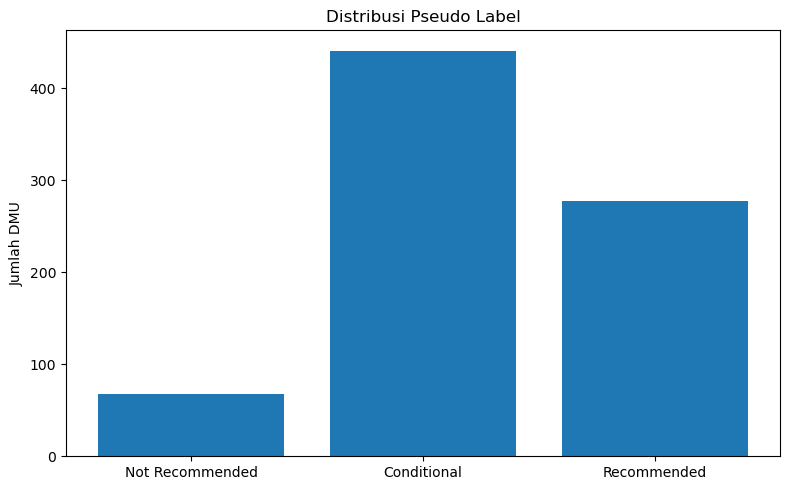

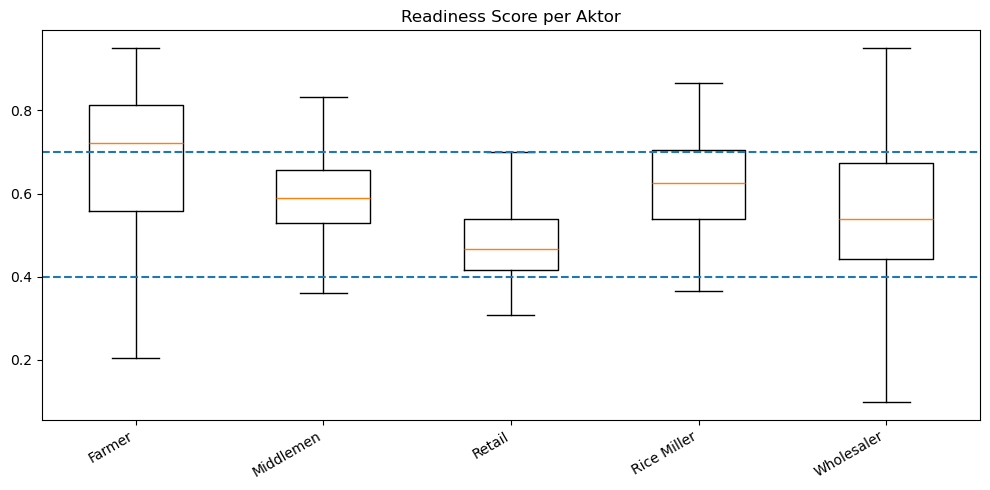

In [6]:
# Profil cluster dan visualisasi hasil pseudo label
profile=(feat.groupby('cluster').agg(n=('dmu','count'), mean_dea=('dea_score','mean'), mean_rc=('rc_ratio','mean'), mean_margin=('margin','mean'), mean_crisis=('crisis_resilience_score','mean'), support_score=('cluster_support_score','mean')).sort_values('support_score'))
display(profile)

counts=feat['readiness_label'].value_counts().sort_index()
plt.figure(figsize=(8,5)); plt.bar(counts.index.astype(str), counts.values)
plt.title('Distribusi Pseudo Label'); plt.ylabel('Jumlah DMU'); plt.tight_layout(); plt.savefig(PLOT_DIR/'02_label_distribution.png', dpi=150); plt.show()

actors=feat['actor'].unique().tolist(); data=[feat.loc[feat['actor']==a,'readiness_score'].dropna() for a in actors]
plt.figure(figsize=(10,5)); plt.boxplot(data, labels=actors, showfliers=False); plt.axhline(0.4, linestyle='--'); plt.axhline(0.7, linestyle='--')
plt.title('Readiness Score per Aktor'); plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.savefig(PLOT_DIR/'02_readiness_score.png', dpi=150); plt.show()

In [7]:
feat.to_csv(OUTPUT_DIR/'02_modeling_dataset.csv', index=False)
feat['readiness_label'].value_counts().rename_axis('readiness_label').reset_index(name='count').to_csv(OUTPUT_DIR/'02_labeling_report.csv', index=False)
profile.to_csv(OUTPUT_DIR/'02_cluster_profile.csv')
with open(OUTPUT_DIR/'02_preprocessing_metadata.json','w',encoding='utf-8') as f:
    json.dump({'silhouette_score':float(sil), 'formula': {'dea_score':0.35,'rc_viability_score':0.25,'crisis_resilience_score':0.20,'asset_utilization_score':0.10,'cluster_support_score':0.10}}, f, indent=2)
print('Saved output for Notebook 03:')
for p in sorted(OUTPUT_DIR.glob('02_*')): print('-', p)

Saved output for Notebook 03:
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\02_cluster_profile.csv
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\02_labeling_report.csv
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\02_modeling_dataset.csv
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\02_preprocessing_metadata.json
